In [1]:
import sys
sys.path.insert(0, "/home/syedkazim/sciebo - Kazim, Syed Muhammad (u491036@uni-siegen.de)@uni-siegen.sciebo.de/Lab/Projects/2024_Phase_Camera_FM_Design/coded_wfs_sim")

from coded_wfs_sim import geometry
from coded_wfs_sim import propagator
from coded_wfs_sim import visualization
from coded_wfs_sim import utils

import numpy as np
from tifffile import tifffile
from matplotlib import pyplot as plt
import cv2

from scipy.signal import correlate2d
from scipy.interpolate import RegularGridInterpolator

qt.qpa.plugin: Could not find the Qt platform plugin "wayland" in ""


* Ensuring proper sampling, wavefield size, and boundary conditions
* *Simulate and save phase mask with proper sizes*
    * Try different densities of structures
    * *Compare outputs from different samplings*
* Ensure proper simulation w.r.t. medium RIs
* Compare BPM vs Thin sample modeling
    * *Make videos for propagation distances*
* Problem specification: FOV and same sampling, but spatial resolution/ spatial frequency limited by distance and speckle size?
    * Speckle size increases with distance?
* Averaging opoerator with stride to map output onto sensor pixels
* Finding minimum sampling frequency: Confirm when sampling frequency starts to effect output

# Sampling Frequency Effects

In [2]:
# lateral spatial resolution 250e-9, 500e-9, 1000e-9

In [3]:
# Grid and propagation parameters setup
wl = 640e-9
spatial_resolution = [1000e-9, 1000e-9, 50e-9] # dx, dy, dz
grid_shape = [125, 125, 250] # x=0->, y=0->, z=0->
n_background = 1. # immersion medium RI

# Create the Geometry object with a shared grid
geom = geometry.Geometry(grid_shape, spatial_resolution, n_background)
pos = geom.unifrom_plane_sampling_positions(12e-6, prob=0.5)

plane_pnt = [0, 0, 12e-6]
plane_normal = [0, 0, 1]

for i in range(pos.shape[0]):
    print(f"Shapes: {i+1}/{pos.shape[0]}", end="\r")
    geom.add_obj_on_plane('cube', (pos[i, 0], pos[i, 1]), length=12e-6, RI=1.4609, 
                              plane=[plane_pnt, plane_normal], bias=2.75e-6)

geom.add_plane(point=plane_pnt, normal=plane_normal, RI=1.49, thickness=15e-6)

# Retrieve 3d RI distribution
RI_distribution = geom.get_grid()
print('Geometry: Done')

# visualization
visualization.visualize_grid_vol(RI_distribution[::2, ::2, ::2], n_background=n_background, factor=1)

Coordiante system with size: 
 
              X = [0, 1.25e-04], Res_X = 1e-06
              Y = [0, 1.25e-04], Res_Y = 1e-06
              Z = [0, 1.25e-05], Res_Z = 5e-08
              Immersion RI: 1.0
      
Geometry: Done


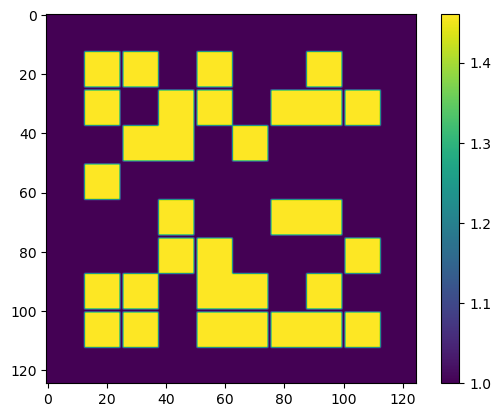

In [4]:
RI_dist = geom.get_grid()[:, :, 86:]
nx, ny, nz = geom.nx, geom.ny, geom.nz
dx, dy, dz = geom.dx, geom.dy, geom.dz

plt.imshow(RI_dist[:, :, 0])
plt.colorbar()
plt.show()

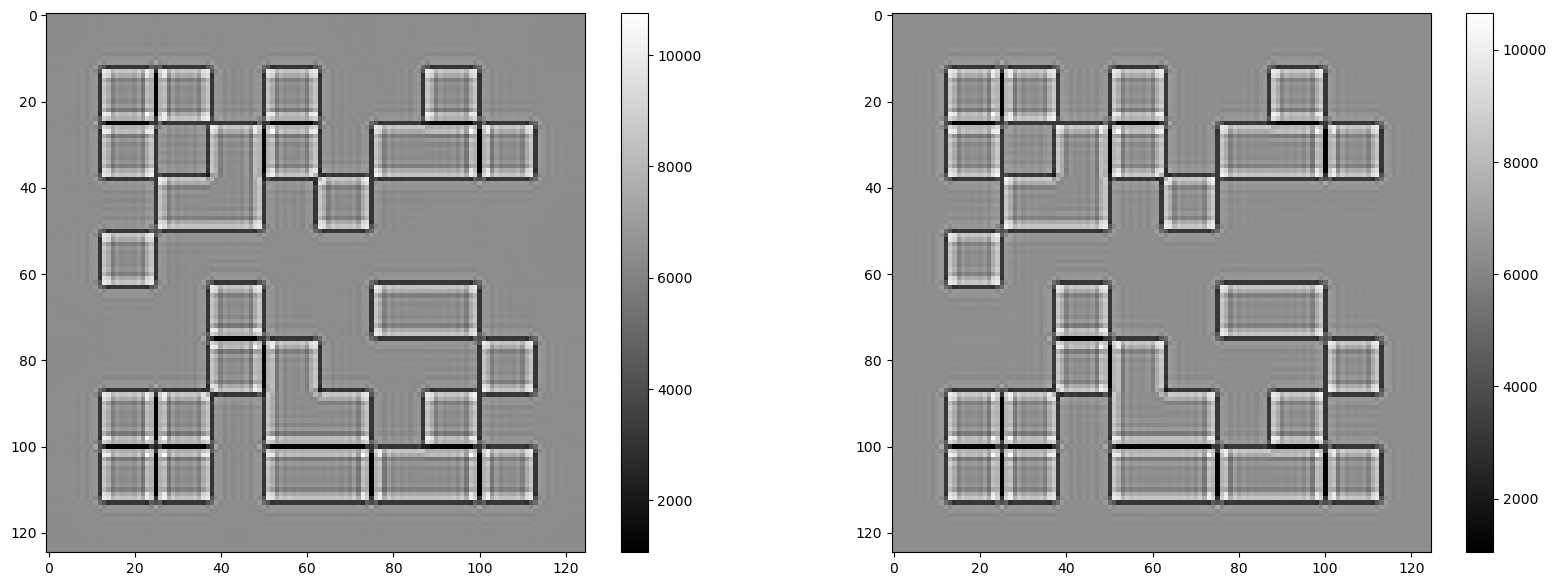

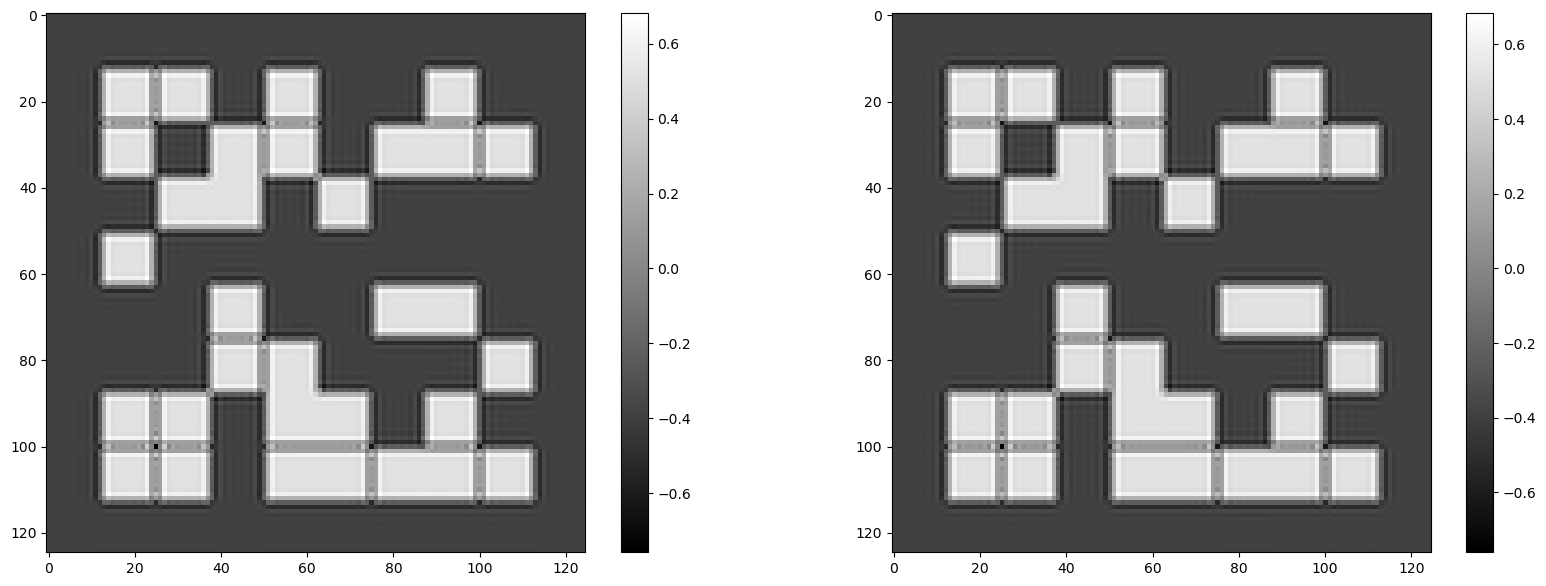

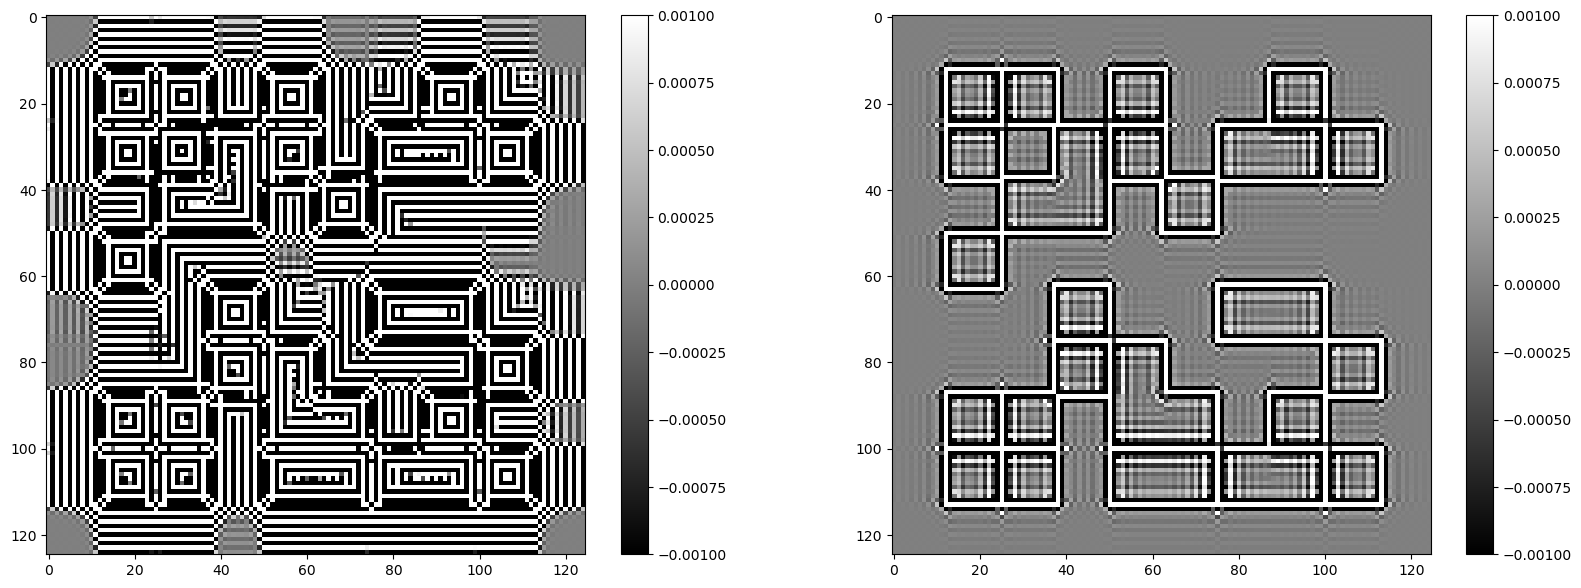

In [5]:
field = np.zeros([nx, ny])
field[:, :] = 80

# Propagate and visualize
output_field = propagator.propagate_beam_2(field, RI_dist, 1.49, wl, [dx, dy, dz], padding=512)

phase_delay = RI_dist[:, :, 0]*50e-9*4*-1
output_field_2 = propagator.propagate(field*np.exp(-1j*(2*np.pi/wl)*phase_delay), wl/1.49, [dx, dy, dz], (RI_dist.shape[2])*50e-9 - 50e-9*4, padding=512)
# *np.exp(-1j*(2*np.pi/wl)*50*50e-9)

fig, axs = plt.subplots(1, 2, figsize=(20, 7))

cm0 = axs[0].imshow(np.abs(output_field)**2, cmap='gray')
plt.colorbar(cm0, ax=axs[0])

cm1 = axs[1].imshow(np.abs(output_field_2)**2, cmap='gray')
plt.colorbar(cm1, ax=axs[1])

plt.show()

fig, axs = plt.subplots(1, 2, figsize=(20, 7))

cm0 = axs[0].imshow(np.angle(output_field), cmap='gray')
plt.colorbar(cm0, ax=axs[0])

cm1 = axs[1].imshow(np.angle(output_field_2), cmap='gray')
plt.colorbar(cm1, ax=axs[1])

plt.show()

fig, axs = plt.subplots(1, 2, figsize=(20, 7))

cm0 = axs[0].imshow(np.abs(output_field) - np.abs(output_field_2), cmap='gray', vmax=1e-3, vmin=-1e-3)
plt.colorbar(cm0, ax=axs[0])

cm1 = axs[1].imshow(np.angle(output_field) - np.angle(output_field_2), cmap='gray', vmax=1e-3, vmin=-1e-3)
plt.colorbar(cm1, ax=axs[1])

plt.show()

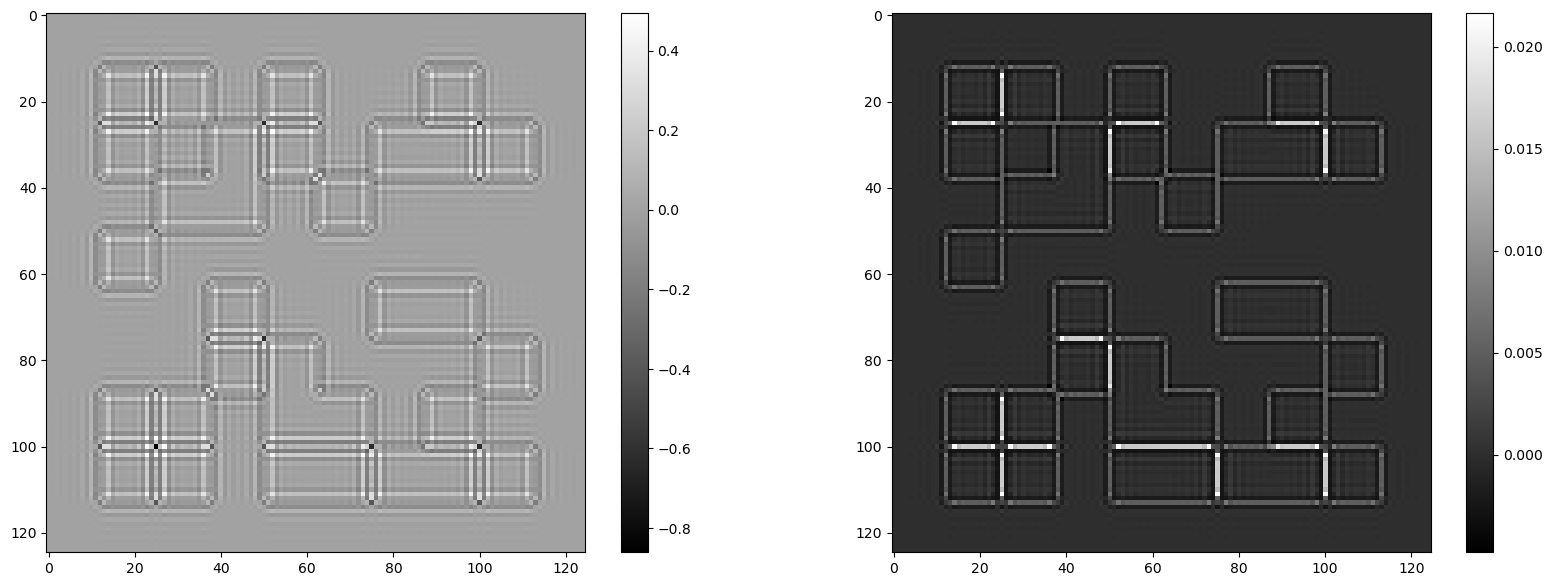

In [6]:
fig, axs = plt.subplots(1, 2, figsize=(20, 7))

cm0 = axs[0].imshow(np.abs(output_field) - np.abs(output_field_2), cmap='gray')
plt.colorbar(cm0, ax=axs[0])

cm1 = axs[1].imshow(np.angle(output_field) - np.angle(output_field_2), cmap='gray')
plt.colorbar(cm1, ax=axs[1])

plt.show()

(381, 381)

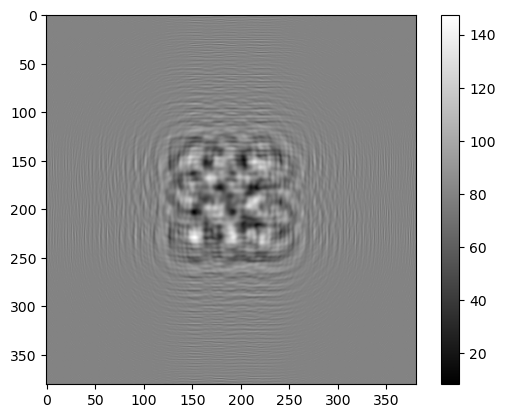

In [7]:
output_field_2_check = propagator.propagate(np.pad(field*np.exp(-1j*(2*np.pi/wl)*phase_delay), 128, 'edge'), 
                                            wl/1.49, [dx, dy, dz], (RI_dist.shape[2])*50e-9 - 50e-9*4 + 1.e-3, padding=None)

plt.imshow(np.abs(output_field_2_check), cmap='gray')
plt.colorbar()
output_field_2_check.shape

In [10]:
cap = cv2.VideoCapture(0)

# Define the codec and create VideoWriter object
#fourcc = cv2.cv.CV_FOURCC(*'DIVX')
#out = cv2.VideoWriter('output.avi',fourcc, 20.0, (640,480))
out = cv2.VideoWriter('v9/v9_2/12um_1000_125_mask_prop_abs.avi', cv2.VideoWriter_fourcc(*'XVID'), 20, (1149, 1149), isColor=False)

for i in range(1, 3000, 10):
    frame = propagator.propagate(np.pad(field*np.exp(-1j*(2*np.pi/wl)*phase_delay), 512, 'edge'), 
                                 wl/1.49, [dx, dy, dz], (RI_dist.shape[2])*50e-9 - 50e-9*4 + i*1e-6, padding=None)
    
    frame = np.abs(frame)**2
    frame = np.array(((frame - frame.min())/(frame.max() - frame.min()))*255, dtype=np.uint8)

    # write the flipped frame
    out.write(frame)

# Release everything if job is finished
out.release()

[ WARN:0@262,778] global cap_v4l.cpp:872 requestBuffers VIDEOIO(V4L2:/dev/video0): failed VIDIOC_REQBUFS: errno=16 (Device or resource busy)
[ WARN:0@262,778] global cap_v4l.cpp:872 requestBuffers VIDEOIO(V4L2:/dev/video0): failed VIDIOC_REQBUFS: errno=16 (Device or resource busy)
[ WARN:0@262,778] global cap_v4l.cpp:872 requestBuffers VIDEOIO(V4L2:/dev/video0): failed VIDIOC_REQBUFS: errno=16 (Device or resource busy)
[ WARN:0@262,778] global cap_v4l.cpp:872 requestBuffers VIDEOIO(V4L2:/dev/video0): failed VIDIOC_REQBUFS: errno=16 (Device or resource busy)
[ WARN:0@262,778] global cap_v4l.cpp:847 requestBuffers VIDEOIO(V4L2:/dev/video0): Insufficient buffer memory
[ WARN:0@262,778] global cap_v4l.cpp:982 open VIDEOIO(V4L2:/dev/video0): can't open camera by index
[ WARN:0@262,785] global obsensor_stream_channel_v4l2.cpp:82 xioctl ioctl: fd=93, req=-2140645888
[ WARN:0@262,785] global obsensor_stream_channel_v4l2.cpp:138 queryUvcDeviceInfoList ioctl error return: 25
[ WARN:0@262,785] gl

In [11]:
# Grid and propagation parameters setup
spatial_resolution = [500e-9, 500e-9, 50e-9] # dx, dy, dz
grid_shape = [250, 250, 250] # x=0->, y=0->, z=0->

# Create the Geometry object with a shared grid
geom = geometry.Geometry(grid_shape, spatial_resolution, n_background)

plane_pnt = [0, 0, 12e-6]
plane_normal = [0, 0, 1]

for i in range(pos.shape[0]):
    print(f"Shapes: {i+1}/{pos.shape[0]}", end="\r")
    geom.add_obj_on_plane('cube', (pos[i, 0], pos[i, 1]), length=12e-6, RI=1.4609, 
                              plane=[plane_pnt, plane_normal], bias=2.75e-6)

geom.add_plane(point=plane_pnt, normal=plane_normal, RI=1.49, thickness=15e-6)

# Retrieve 3d RI distribution
RI_distribution = geom.get_grid()
print('Geometry: Done')

# visualization
visualization.visualize_grid_vol(RI_distribution[::2, ::2, ::2], n_background=n_background, factor=1)

Coordiante system with size: 
 
              X = [0, 1.25e-04], Res_X = 5e-07
              Y = [0, 1.25e-04], Res_Y = 5e-07
              Z = [0, 1.25e-05], Res_Z = 5e-08
              Immersion RI: 1.0
      
Geometry: Done


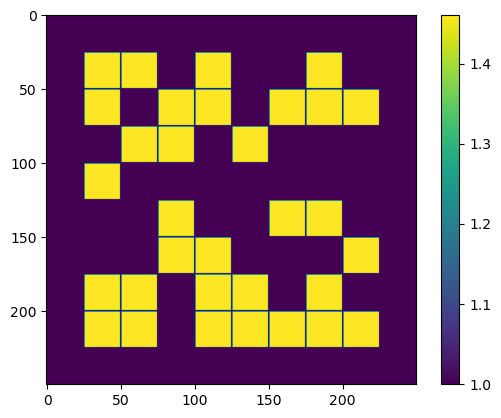

In [12]:
RI_dist = geom.get_grid()[:, :, 86:]
nx, ny, nz = geom.nx, geom.ny, geom.nz
dx, dy, dz = geom.dx, geom.dy, geom.dz

plt.imshow(RI_dist[:, :, 0])
plt.colorbar()
plt.show()

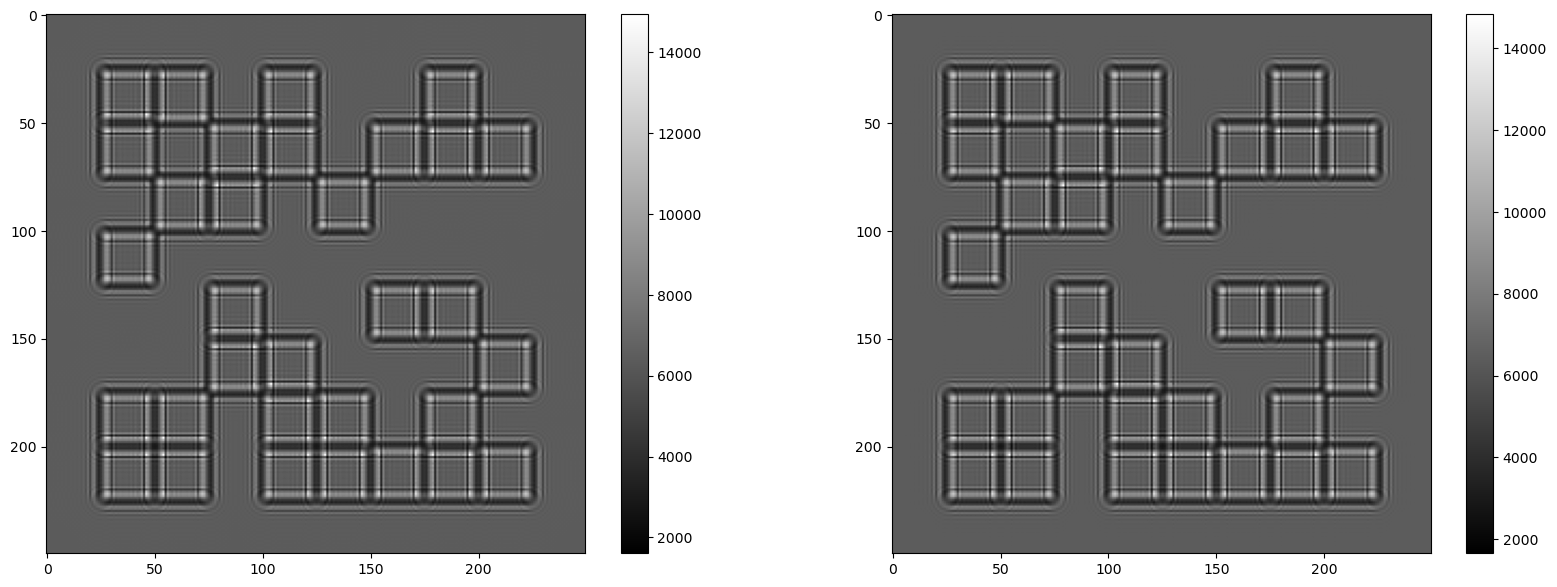

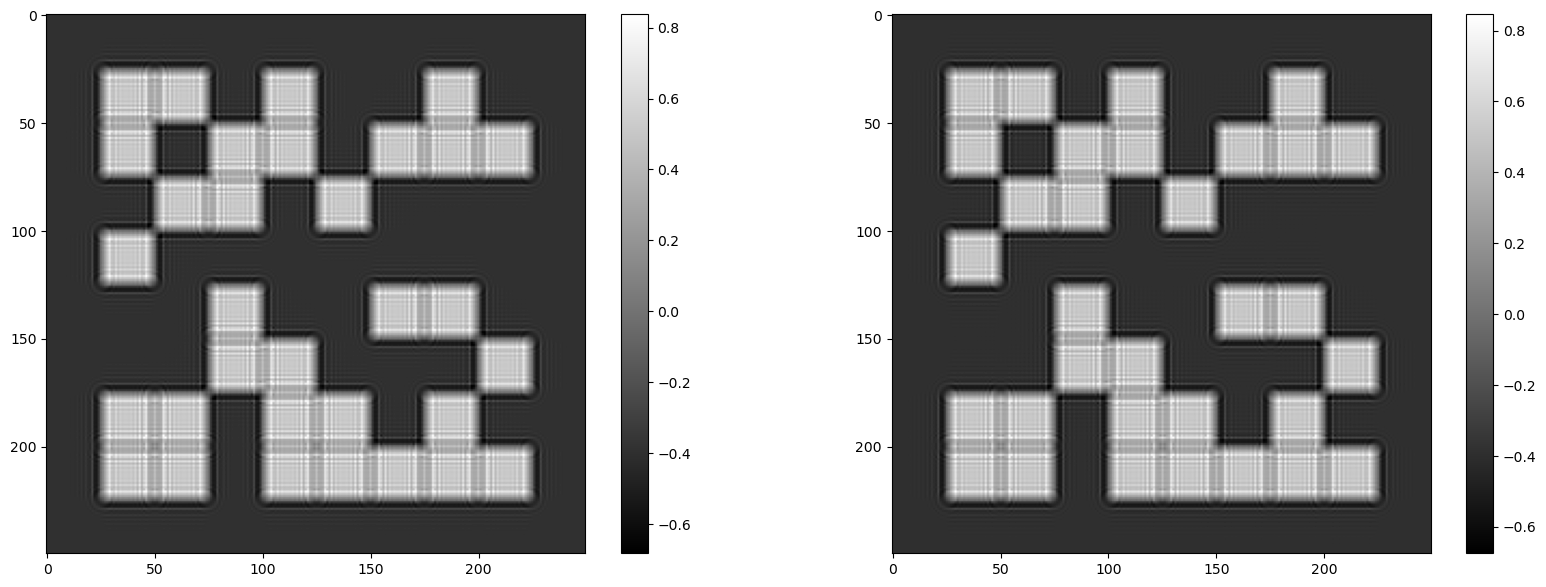

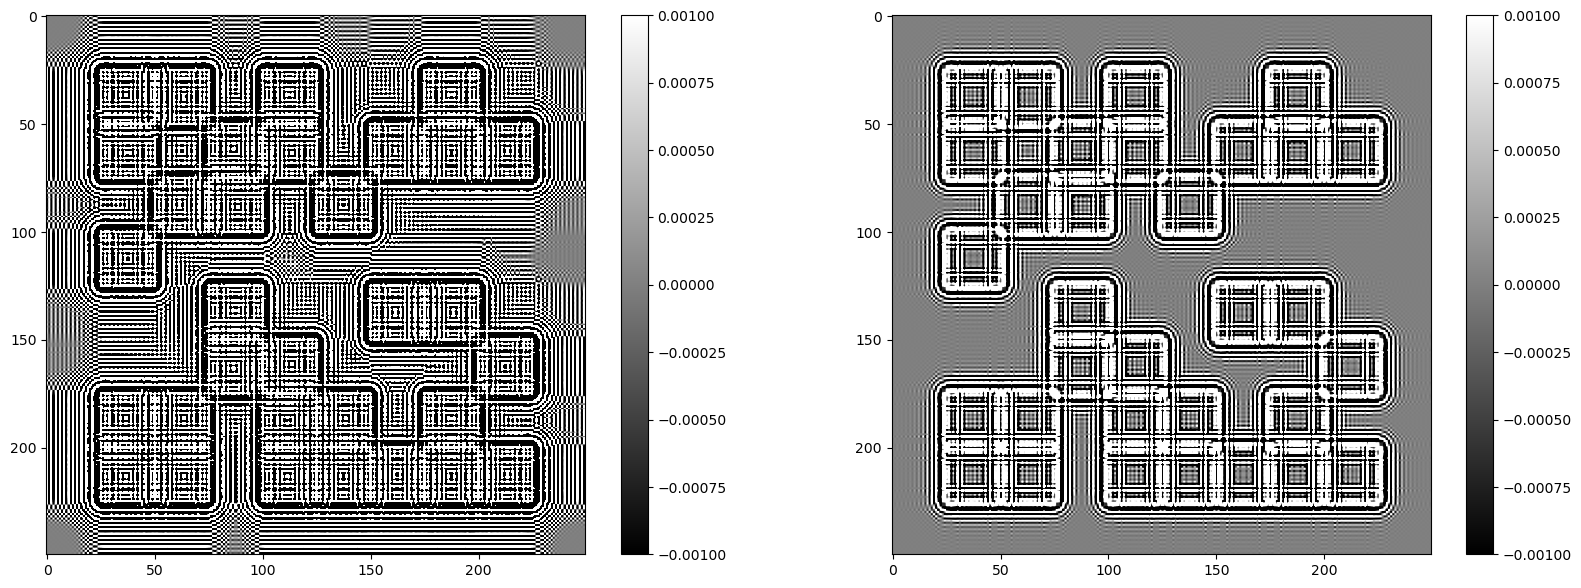

In [13]:
field = np.zeros([nx, ny])
field[:, :] = 80

# Propagate and visualize
output_field = propagator.propagate_beam_2(field, RI_dist, 1.49, wl, [dx, dy, dz], padding=512)

phase_delay = RI_dist[:, :, 0]*50e-9*4*-1
output_field_2 = propagator.propagate(field*np.exp(-1j*(2*np.pi/wl)*phase_delay), wl/1.49, [dx, dy, dz], (RI_dist.shape[2])*50e-9 - 50e-9*4, padding=512)
# *np.exp(-1j*(2*np.pi/wl)*50*50e-9)

fig, axs = plt.subplots(1, 2, figsize=(20, 7))

cm0 = axs[0].imshow(np.abs(output_field)**2, cmap='gray')
plt.colorbar(cm0, ax=axs[0])

cm1 = axs[1].imshow(np.abs(output_field_2)**2, cmap='gray')
plt.colorbar(cm1, ax=axs[1])

plt.show()

fig, axs = plt.subplots(1, 2, figsize=(20, 7))

cm0 = axs[0].imshow(np.angle(output_field), cmap='gray')
plt.colorbar(cm0, ax=axs[0])

cm1 = axs[1].imshow(np.angle(output_field_2), cmap='gray')
plt.colorbar(cm1, ax=axs[1])

plt.show()

fig, axs = plt.subplots(1, 2, figsize=(20, 7))

cm0 = axs[0].imshow(np.abs(output_field) - np.abs(output_field_2), cmap='gray', vmax=1e-3, vmin=-1e-3)
plt.colorbar(cm0, ax=axs[0])

cm1 = axs[1].imshow(np.angle(output_field) - np.angle(output_field_2), cmap='gray', vmax=1e-3, vmin=-1e-3)
plt.colorbar(cm1, ax=axs[1])

plt.show()

(506, 506)

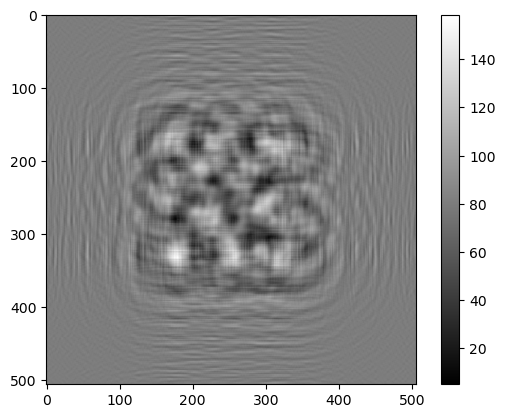

In [14]:
output_field_2_check = propagator.propagate(np.pad(field*np.exp(-1j*(2*np.pi/wl)*phase_delay), 128, 'edge'), 
                                            wl/1.49, [dx, dy, dz], (RI_dist.shape[2])*50e-9 - 50e-9*4 + 1.e-3, padding=None)

plt.imshow(np.abs(output_field_2_check), cmap='gray')
plt.colorbar()
output_field_2_check.shape

In [17]:
cap = cv2.VideoCapture(0)

# Define the codec and create VideoWriter object
#fourcc = cv2.cv.CV_FOURCC(*'DIVX')
#out = cv2.VideoWriter('output.avi',fourcc, 20.0, (640,480))
out = cv2.VideoWriter('v9/v9_2/12um_500_250_mask_prop_abs.avi', cv2.VideoWriter_fourcc(*'XVID'), 20, (1274, 1274), isColor=False)

for i in range(1, 3000, 10):
    frame = propagator.propagate(np.pad(field*np.exp(-1j*(2*np.pi/wl)*phase_delay), 512, 'edge'), 
                                 wl/1.49, [dx, dy, dz], (RI_dist.shape[2])*50e-9 - 50e-9*4 + i*1e-6, padding=None)
    
    frame = np.abs(frame)**2
    frame = np.array(((frame - frame.min())/(frame.max() - frame.min()))*255, dtype=np.uint8)

    # write the flipped frame
    out.write(frame)

# Release everything if job is finished
out.release()

[ WARN:0@504,524] global cap_v4l.cpp:872 requestBuffers VIDEOIO(V4L2:/dev/video0): failed VIDIOC_REQBUFS: errno=16 (Device or resource busy)
[ WARN:0@504,524] global cap_v4l.cpp:872 requestBuffers VIDEOIO(V4L2:/dev/video0): failed VIDIOC_REQBUFS: errno=16 (Device or resource busy)
[ WARN:0@504,524] global cap_v4l.cpp:872 requestBuffers VIDEOIO(V4L2:/dev/video0): failed VIDIOC_REQBUFS: errno=16 (Device or resource busy)
[ WARN:0@504,524] global cap_v4l.cpp:872 requestBuffers VIDEOIO(V4L2:/dev/video0): failed VIDIOC_REQBUFS: errno=16 (Device or resource busy)
[ WARN:0@504,524] global cap_v4l.cpp:847 requestBuffers VIDEOIO(V4L2:/dev/video0): Insufficient buffer memory
[ WARN:0@504,524] global cap_v4l.cpp:982 open VIDEOIO(V4L2:/dev/video0): can't open camera by index
[ WARN:0@504,525] global obsensor_stream_channel_v4l2.cpp:82 xioctl ioctl: fd=94, req=-2140645888
[ WARN:0@504,525] global obsensor_stream_channel_v4l2.cpp:138 queryUvcDeviceInfoList ioctl error return: 25
[ WARN:0@504,525] gl

In [18]:
# Grid and propagation parameters setup
spatial_resolution = [250e-9, 250e-9, 50e-9] # dx, dy, dz
grid_shape = [500, 500, 500] # x=0->, y=0->, z=0->

# Create the Geometry object with a shared grid
geom = geometry.Geometry(grid_shape, spatial_resolution, n_background)

plane_pnt = [0, 0, 12e-6]
plane_normal = [0, 0, 1]

for i in range(pos.shape[0]):
    print(f"Shapes: {i+1}/{pos.shape[0]}", end="\r")
    geom.add_obj_on_plane('cube', (pos[i, 0], pos[i, 1]), length=12e-6, RI=1.4609, 
                              plane=[plane_pnt, plane_normal], bias=2.75e-6)

geom.add_plane(point=plane_pnt, normal=plane_normal, RI=1.49, thickness=15e-6)

# Retrieve 3d RI distribution
RI_distribution = geom.get_grid()
print('Geometry: Done')

# visualization
visualization.visualize_grid_vol(RI_distribution[::2, ::2, ::2], n_background=n_background, factor=1)

Coordiante system with size: 
 
              X = [0, 1.25e-04], Res_X = 2.5e-07
              Y = [0, 1.25e-04], Res_Y = 2.5e-07
              Z = [0, 2.50e-05], Res_Z = 5e-08
              Immersion RI: 1.0
      
Geometry: Done


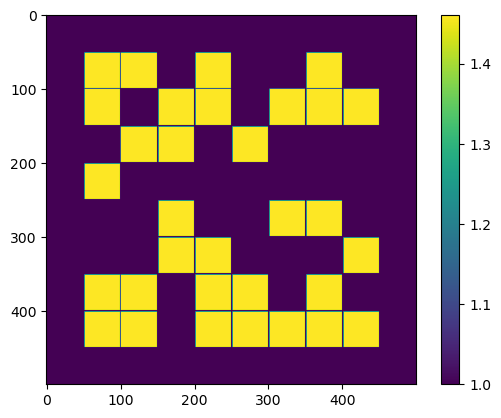

In [19]:
RI_dist = geom.get_grid()[:, :, 86:]
nx, ny, nz = geom.nx, geom.ny, geom.nz
dx, dy, dz = geom.dx, geom.dy, geom.dz

plt.imshow(RI_dist[:, :, 0])
plt.colorbar()
plt.show()

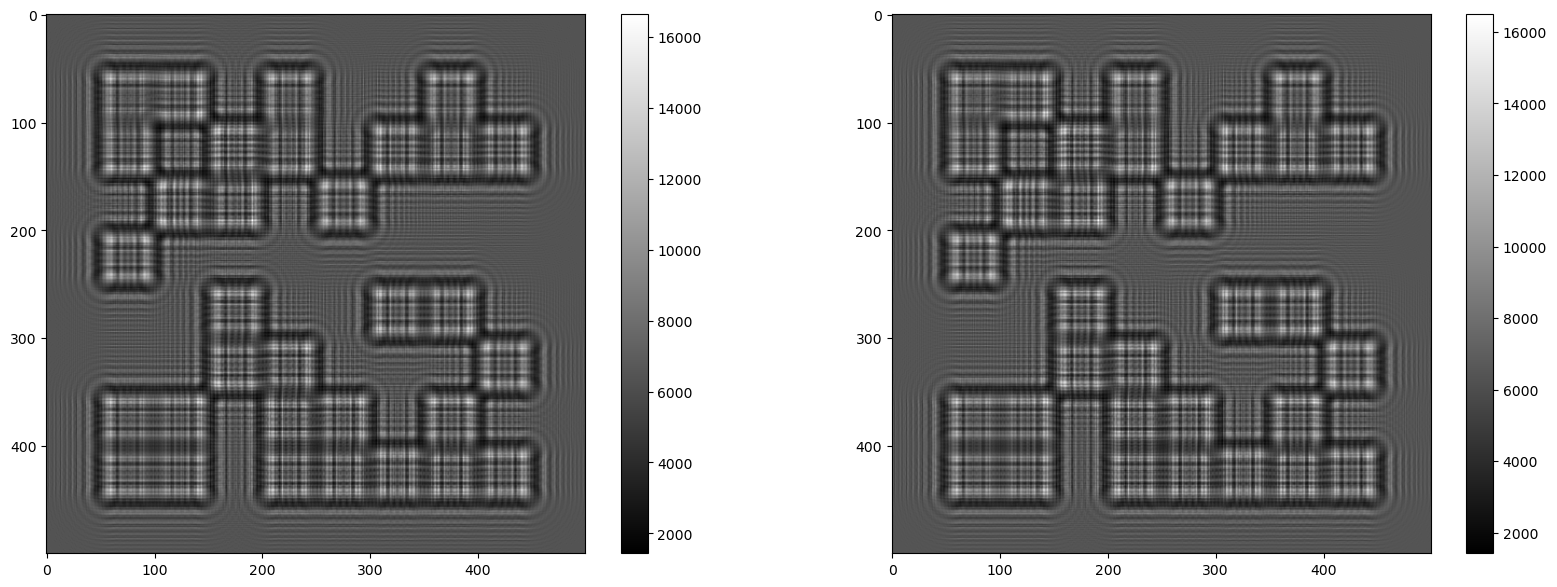

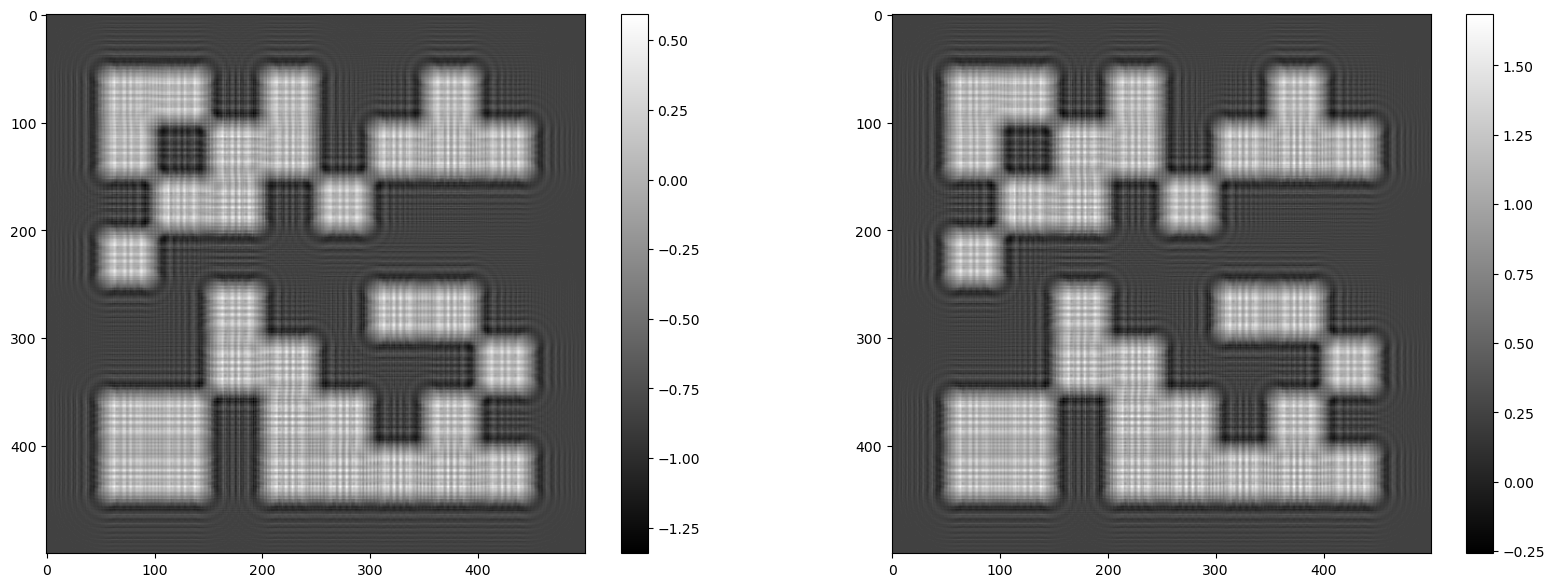

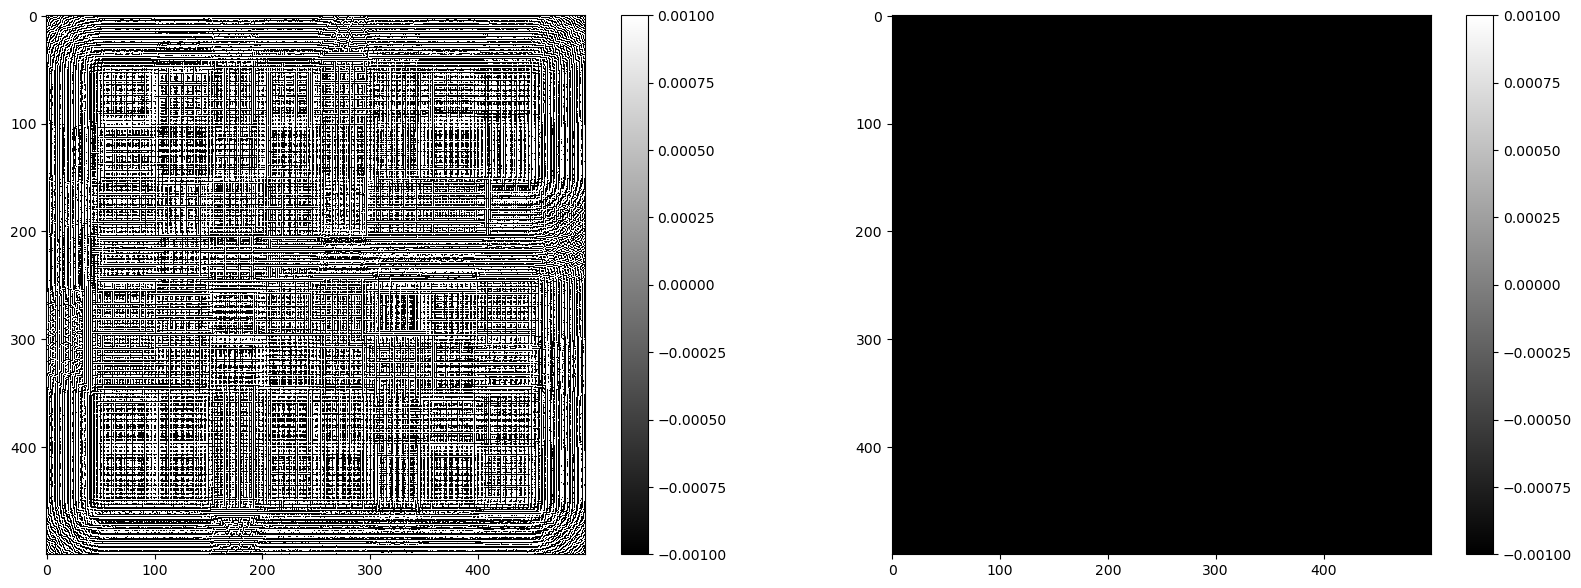

In [20]:
field = np.zeros([nx, ny])
field[:, :] = 80

# Propagate and visualize
output_field = propagator.propagate_beam_2(field, RI_dist, 1.49, wl, [dx, dy, dz], padding=512)

phase_delay = RI_dist[:, :, 0]*50e-9*4*-1
output_field_2 = propagator.propagate(field*np.exp(-1j*(2*np.pi/wl)*phase_delay), wl/1.49, [dx, dy, dz], (RI_dist.shape[2])*50e-9 - 50e-9*4, padding=512)
# *np.exp(-1j*(2*np.pi/wl)*50*50e-9)

fig, axs = plt.subplots(1, 2, figsize=(20, 7))

cm0 = axs[0].imshow(np.abs(output_field)**2, cmap='gray')
plt.colorbar(cm0, ax=axs[0])

cm1 = axs[1].imshow(np.abs(output_field_2)**2, cmap='gray')
plt.colorbar(cm1, ax=axs[1])

plt.show()

fig, axs = plt.subplots(1, 2, figsize=(20, 7))

cm0 = axs[0].imshow(np.angle(output_field), cmap='gray')
plt.colorbar(cm0, ax=axs[0])

cm1 = axs[1].imshow(np.angle(output_field_2), cmap='gray')
plt.colorbar(cm1, ax=axs[1])

plt.show()

fig, axs = plt.subplots(1, 2, figsize=(20, 7))

cm0 = axs[0].imshow(np.abs(output_field) - np.abs(output_field_2), cmap='gray', vmax=1e-3, vmin=-1e-3)
plt.colorbar(cm0, ax=axs[0])

cm1 = axs[1].imshow(np.angle(output_field) - np.angle(output_field_2), cmap='gray', vmax=1e-3, vmin=-1e-3)
plt.colorbar(cm1, ax=axs[1])

plt.show()

(756, 756)

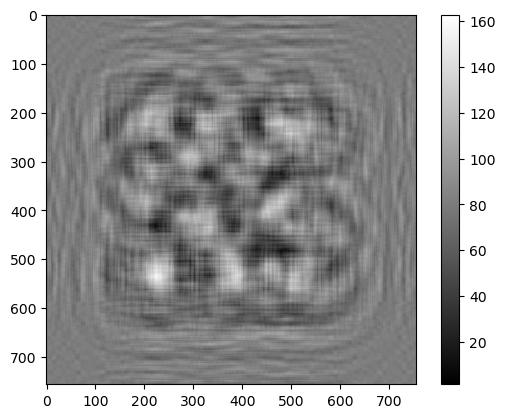

In [21]:
output_field_2_check = propagator.propagate(np.pad(field*np.exp(-1j*(2*np.pi/wl)*phase_delay), 128, 'edge'), 
                                            wl/1.49, [dx, dy, dz], (RI_dist.shape[2])*50e-9 - 50e-9*4 + 1.e-3, padding=None)

plt.imshow(np.abs(output_field_2_check), cmap='gray')
plt.colorbar()
output_field_2_check.shape

In [24]:
cap = cv2.VideoCapture(0)

# Define the codec and create VideoWriter object
#fourcc = cv2.cv.CV_FOURCC(*'DIVX')
#out = cv2.VideoWriter('output.avi',fourcc, 20.0, (640,480))
out = cv2.VideoWriter('v9/v9_2/12um_250_500_mask_prop_abs.avi', cv2.VideoWriter_fourcc(*'XVID'), 20, (1524, 1524), isColor=False)

for i in range(1, 3000, 10):
    frame = propagator.propagate(np.pad(field*np.exp(-1j*(2*np.pi/wl)*phase_delay), 512, 'edge'), 
                                 wl/1.49, [dx, dy, dz], (RI_dist.shape[2])*50e-9 - 50e-9*4 + i*1e-6, padding=None)
    
    frame = np.abs(frame)**2
    frame = np.array(((frame - frame.min())/(frame.max() - frame.min()))*255, dtype=np.uint8)

    # write the flipped frame
    out.write(frame)

# Release everything if job is finished
out.release()

[ WARN:0@786,482] global cap_v4l.cpp:872 requestBuffers VIDEOIO(V4L2:/dev/video0): failed VIDIOC_REQBUFS: errno=16 (Device or resource busy)
[ WARN:0@786,482] global cap_v4l.cpp:872 requestBuffers VIDEOIO(V4L2:/dev/video0): failed VIDIOC_REQBUFS: errno=16 (Device or resource busy)
[ WARN:0@786,482] global cap_v4l.cpp:872 requestBuffers VIDEOIO(V4L2:/dev/video0): failed VIDIOC_REQBUFS: errno=16 (Device or resource busy)
[ WARN:0@786,482] global cap_v4l.cpp:872 requestBuffers VIDEOIO(V4L2:/dev/video0): failed VIDIOC_REQBUFS: errno=16 (Device or resource busy)
[ WARN:0@786,482] global cap_v4l.cpp:847 requestBuffers VIDEOIO(V4L2:/dev/video0): Insufficient buffer memory
[ WARN:0@786,482] global cap_v4l.cpp:982 open VIDEOIO(V4L2:/dev/video0): can't open camera by index
[ WARN:0@786,482] global obsensor_stream_channel_v4l2.cpp:82 xioctl ioctl: fd=94, req=-2140645888
[ WARN:0@786,482] global obsensor_stream_channel_v4l2.cpp:138 queryUvcDeviceInfoList ioctl error return: 25
[ WARN:0@786,482] gl

In [26]:
500e-9*500/1e-6

250.00000000000003